1. Standard scaling is a method of scaling the data such that the distribution of the data is centered around 0, with a standard deviation of 1. This is done by subtracting the mean of the data from each data point and then dividing by the standard deviation of the data. This is a very common method of scaling data, and is used in many machine learning algorithms.

The formula is as follows:

z = (x - μ) / σ

In [ ]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler,MaxAbsScaler

In [ ]:
#make a random dataset
data = {
    'age': [25,30,35,40,45],
    'height' : [165,170,175,180,185],
    'weight' : [55,60,65,70,75]
}
#convert this data to pandas df
df=pd.DataFrame(data)
df.head()

,age,height,weight
0,25,165,55
1,30,170,60
2,35,175,65
3,40,180,70
4,45,185,75


#  Standard _ Scalar


In [ ]:
# import scaler
scaler = StandardScaler()
#fit the scaler on data
scaled_df = scaler.fit_transform(df)
scaled_df
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.414214,-1.414214,-1.414214
1,-0.707107,-0.707107,-0.707107
2,0.000000,0.000000,0.000000
3,0.707107,0.707107,0.707107
4,1.414214,1.414214,1.414214


#  MIN_MAX Scaler


In [ ]:
scalar = MinMaxScaler()
scaled_df = scalar.fit_transform(df)
scaled_df
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.00,0.00,0.00
1,0.25,0.25,0.25
2,0.50,0.50,0.50
3,0.75,0.75,0.75
4,1.00,1.00,1.00


Max-ABS-scalar

In [ ]:
scalar = MaxAbsScaler()
scaled_df=scalar.fit_transform(df)
scaled_df
scaled_df=pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.555556,0.891892,0.733333
1,0.666667,0.918919,0.800000
2,0.777778,0.945946,0.866667
3,0.888889,0.972973,0.933333
4,1.000000,1.000000,1.000000


# Robust Scalar

In [ ]:
from sklearn.preprocessing import RobustScaler
scalar = RobustScaler()
scaled_df=scalar.fit_transform(df)
scaled_df
scaled_df=pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.0,-1.0,-1.0
1,-0.5,-0.5,-0.5
2,0.0,0.0,0.0
3,0.5,0.5,0.5
4,1.0,1.0,1.0


#   TRANSFORMATION

In [ ]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np


In [ ]:
#generate non-normal data(exponential distribution)
np.random.seed(0)
df=np.random.exponential(size=1000, scale=2)
df=pd.DataFrame(df, columns=['values'])
df.head(20)

,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097
5,2.076319
6,1.151038
7,4.447049
8,6.629824
9,0.967204


<Axes: xlabel='values', ylabel='Count'>

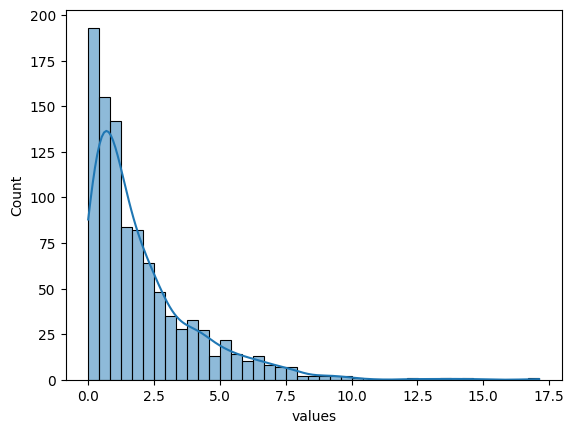

In [ ]:
sns.histplot(df['values'], kde=True)

In [ ]:
from sklearn.preprocessing import PowerTransformer , QuantileTransformer

pt_boxcox = PowerTransformer(method='box-cox', standardize=False)
pt_yeo_johnson = PowerTransformer(method= "yeo-johnson", standardize=False)
qt_normal = QuantileTransformer(output_distribution='normal')

# boxcor k liay data must be +ve
df['box_cox'] = pt_boxcox.fit_transform(df[['values']]+1)
df['yeo_johnson'] = pt_yeo_johnson.fit_transform(df[['values']])
df['quantile'] = qt_normal.fit_transform(df[['values']])

In [ ]:
df.head()

,values,box_cox,yeo_johnson,quantile
0,1.591749,0.787485,0.787485,0.162552
1,2.511862,0.980233,0.980233,0.587964
2,1.846446,0.849553,0.849553,0.286135
3,1.574402,0.782945,0.782945,0.157469
4,1.102097,0.639848,0.639848,-0.154930


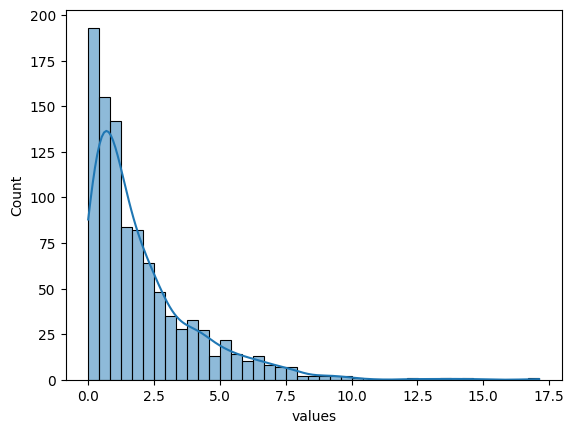

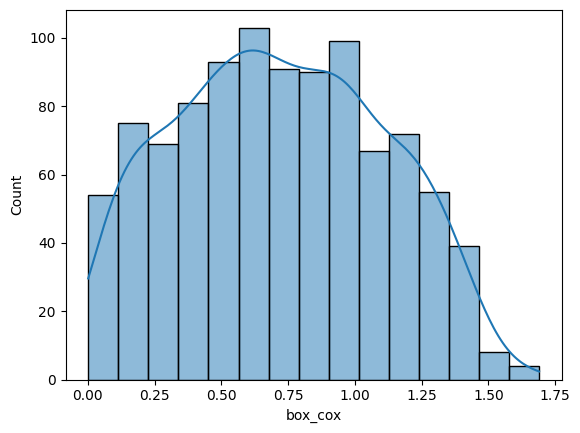

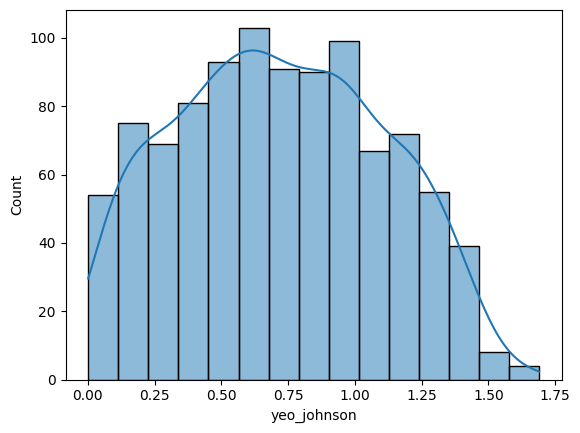

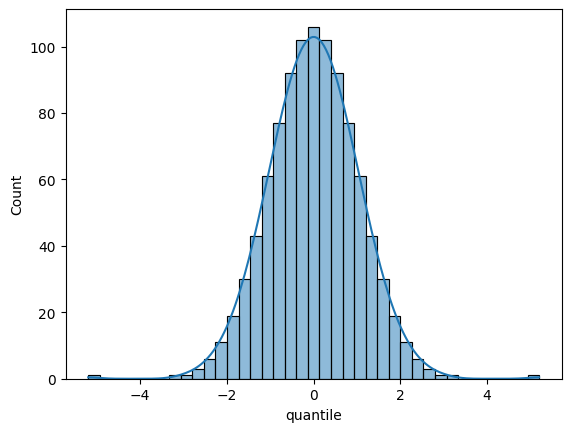

In [ ]:
import matplotlib.pyplot as plt
for col in df.columns:
   sns.histplot(df[col],kde=True)
   plt.show()

#  NORMALIZATION

Normalization
Data Normalization is a technique often applied as part of data preparation for machine learning. The goal of normalization is to change the values of numeric columns in the dataset to a common scale, without distorting differences in the ranges of values. For machine learning, every dataset does not require normalization. It is required only when features have different ranges.

L2 Normalization:
Rescales each sample (row) to have unit norm. This type of normalization is often used when dealing with text data. The L2 norm is calculated as the square root of the sum of the squared vector values.

In [ ]:
from sklearn.preprocessing import Normalizer
data= [[1,1,1],[1,1,0],[1,0,0]]
normalizer = Normalizer(norm='l2')
print(normalizer.fit_transform(data))

[[0.57735027 0.57735027 0.57735027]
 [0.70710678 0.70710678 0.        ]
 [1.         0.         0.        ]]


L1 Normalization:
Also rescales each sample (row) but with a different approach, ensuring the sum of the absolute values is 1 in each row. The L1 norm is calculated as the sum of the absolute vector values. Example:

In [ ]:
from sklearn.preprocessing import Normalizer
data = [[1, 1, 1], [1, 1, 0], [1, 0, 0]]
normalizer=Normalizer(norm='l1')
print(normalizer.fit_transform(data))

[[0.33333333 0.33333333 0.33333333]
 [0.5        0.5        0.        ]
 [1.         0.         0.        ]]


#  Z-score normalization


1.   Standard Scalar



#  Min-Max normalization


1.  Min-Max Scalar




# --- LOG TRANSFORMATION

In [ ]:
import pandas as pd
import numpy as np
df={'values':[1,5,10,20,50,100,200,500,1000,2000,5000,10000,20000,50000,100000,1000000]}
df=pd.DataFrame(df)
df.head()

,values
0,1
1,5
2,10
3,20
4,50


In [ ]:
df['log_values'] = np.log(df['values'])
df

,values,log_values
0,1,0.000000
1,5,1.609438
2,10,2.302585
3,20,2.995732
4,50,3.912023
5,100,4.605170
6,200,5.298317
7,500,6.214608
8,1000,6.907755
9,2000,7.600902


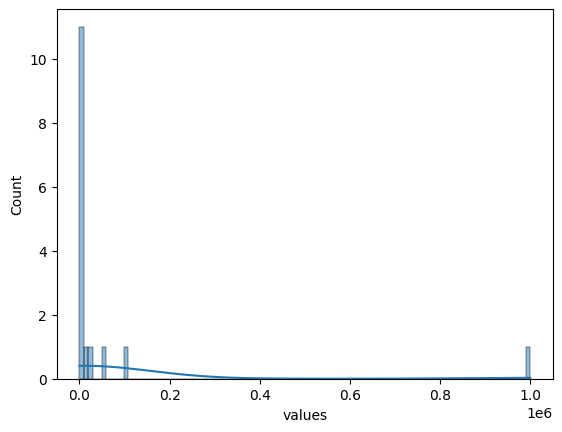

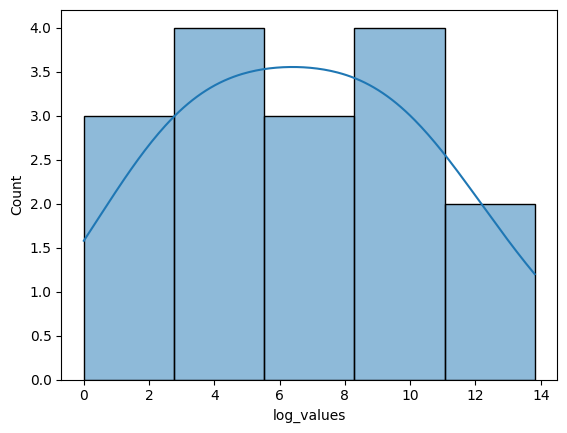

In [ ]:
for col in df.columns:
  sns.histplot(df[col],kde=True)
  plt.show()